# 05 — SHAP Feature Importance Analysis
SHAP analysis untuk best model dari Phase 2 pada data test set (20% akhir).

In [1]:
import sys, unittest.mock; sys.modules.setdefault('transformers.dependency_versions_check', unittest.mock.MagicMock())

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import joblib
import warnings
from datetime import datetime
warnings.filterwarnings("ignore")

from darts import TimeSeries
from darts.models import RandomForestModel, XGBModel, LightGBMModel
from darts.dataprocessing.transformers import Scaler, Diff
from darts.utils.missing_values import fill_missing_values
from sklearn.ensemble import ExtraTreesRegressor

try:
    from darts.models import SKLearnModel
except ImportError:
    from darts.models import RegressionModel as SKLearnModel

try:
    import shap
    print("shap version:", shap.__version__)
except ImportError:
    raise ImportError("Install shap: pip install shap")

LEVEL_VARS  = ["M2", "USDIDR", "Coal", "Copper", "Nickel", "Silver", "Tin", "STI", "Gold", "WTI", "GDP"]
RATE_VARS   = ["BI_Rate", "CPI", "NPL_Ratio", "US_Treasury_10Y"]
HORIZON     = 1
TRAIN_RATIO = 0.8

import glob
df_merged = joblib.load(sorted(glob.glob("saved_models/df_merged_*.joblib"), reverse=True)[0])
TUNING     = joblib.load("saved_models/optuna_tuning_results.joblib")
best_cfg   = joblib.load("saved_models/best_config_phase2.joblib")
GROUP_COV  = joblib.load("saved_models/phase2_groups.joblib")

print("Best config:", best_cfg)


shap version: 0.46.0
Best config: {'Model': 'RandomForest', 'Covariates': 'Sig_Commodity', 'Window': 30, 'mape': 0.5044, 'mae': 35.8555, 'rmse': 47.8617, 'r2': 0.972, 'da': 54.18}


## Retrain Best Model on Full Train Set

In [2]:

MODEL_NAME = best_cfg['Model']
COV_NAME   = best_cfg['Covariates']
WINDOW     = int(best_cfg['Window'])
cov_vars   = GROUP_COV[COV_NAME]

print(f"Retraining: {MODEL_NAME} | {COV_NAME} | W{WINDOW}")

def to_series(df, target_col, covariates=None):
    target = TimeSeries.from_dataframe(df, time_col="date", value_cols=target_col,
        fill_missing_dates=True, freq="B")
    target = fill_missing_values(target)
    cov = None
    if covariates:
        cov = TimeSeries.from_dataframe(df, time_col="date", value_cols=covariates,
            fill_missing_dates=True, freq="B")
        cov = fill_missing_values(cov)
    return target, cov

target_ts, cov_ts = to_series(df_merged, "IHSG", cov_vars)
n = len(target_ts)
split_idx = int(n * TRAIN_RATIO)

# Transform target
train_ts  = target_ts[:split_idx]
full_log  = target_ts.map(np.log)
train_log = train_ts.map(np.log)
diff_t = Diff(lags=1)
train_log_diff = diff_t.fit_transform(train_log)
full_log_diff  = diff_t.transform(full_log)
scaler = Scaler()
train_scaled = scaler.fit_transform(train_log_diff)
full_scaled  = scaler.transform(full_log_diff)

# Transform covariates
cov_cols    = cov_ts.components.tolist()
level_cols  = [c for c in cov_cols if c in LEVEL_VARS]
rate_cols   = [c for c in cov_cols if c in RATE_VARS]
train_cov   = cov_ts[:split_idx]
full_cov    = cov_ts
parts_train, parts_full = [], []
if level_cols:
    d = Diff(lags=1)
    parts_train.append(d.fit_transform(train_cov[level_cols].map(np.log)))
    parts_full.append(d.transform(full_cov[level_cols].map(np.log)))
if rate_cols:
    d = Diff(lags=1)
    parts_train.append(d.fit_transform(train_cov[rate_cols]))
    parts_full.append(d.transform(full_cov[rate_cols]))
ct = parts_train[0]
cf = parts_full[0]
for pt, pf in zip(parts_train[1:], parts_full[1:]):
    ct = ct.stack(pt)
    cf = cf.stack(pf)
cov_scaler = Scaler()
cov_scaler.fit(ct)
full_cov_scaled = cov_scaler.transform(cf)

# Build and fit best model
best_params = TUNING[MODEL_NAME]['best_params'].copy()
common = {"lags": WINDOW, "lags_past_covariates": WINDOW, "output_chunk_length": HORIZON}
if MODEL_NAME == "RandomForest":
    model = RandomForestModel(**common, random_state=42, n_jobs=-1, **best_params)
elif MODEL_NAME == "ExtraTrees":
    model = SKLearnModel(**common, model=ExtraTreesRegressor(random_state=42, n_jobs=-1, **best_params))
elif MODEL_NAME == "XGBoost":
    model = XGBModel(**common, random_state=42, n_jobs=-1, **best_params)
elif MODEL_NAME == "LightGBM":
    model = LightGBMModel(**common, random_state=42, n_jobs=-1, verbose=-1, **best_params)

model.fit(train_scaled, past_covariates=full_cov_scaled)
print("Model fitted successfully.")


Retraining: RandomForest | Sig_Commodity | W30


Model fitted successfully.


## Reconstruct Feature Matrix for SHAP

In [3]:

# Reconstruct X_test by rolling window over scaled time series
target_arr = full_scaled.values().flatten()
cov_arr    = full_cov_scaled.values()  # shape: (T, n_covariates)
cov_names  = full_cov_scaled.components.tolist()

# Feature matrix: [target_lag_1..W, cov1_lag_1..W, cov2_lag_1..W, ...]
def build_lag_matrix(target_arr, cov_arr, cov_names, lags, start_idx, end_idx):
    rows = []
    feat_names = []
    built_names = False
    for t in range(start_idx, end_idx):
        row = []
        for lag in range(1, lags + 1):
            row.append(target_arr[t - lag])
            if not built_names:
                feat_names.append(f"IHSG_lag_{lag}")
        for j, cname in enumerate(cov_names):
            for lag in range(1, lags + 1):
                row.append(cov_arr[t - lag, j])
                if not built_names:
                    feat_names.append(f"{cname}_lag_{lag}")
        rows.append(row)
        built_names = True
    return np.array(rows), feat_names

# Only use test period (split_idx onward), need lags before test start
# Offset for diff (first row is NaN after Diff, so actual data starts 1 later)
ts_start = WINDOW + 1  # need at least WINDOW lag values before first prediction
test_start = max(split_idx, ts_start)

X_test, feat_names = build_lag_matrix(target_arr, cov_arr, cov_names, WINDOW, test_start, len(target_arr))
print(f"X_test shape: {X_test.shape}")
print(f"Feature count: {len(feat_names)}")
print(f"First 5 feature names: {feat_names[:5]}")


X_test shape: (526, 180)
Feature count: 180
First 5 feature names: ['IHSG_lag_1', 'IHSG_lag_2', 'IHSG_lag_3', 'IHSG_lag_4', 'IHSG_lag_5']


In [4]:

# Access underlying sklearn/xgb/lgb model
underlying_model = model.model
# For Darts regression models: model.model returns the fitted sklearn-compatible model
# For multi_models=True with horizon=1, it may be a single model or list
if hasattr(underlying_model, '__iter__') and not hasattr(underlying_model, 'predict'):
    underlying_model = underlying_model[0]
print("Underlying model type:", type(underlying_model).__name__)

# Build SHAP explainer
explainer = shap.TreeExplainer(underlying_model)
# Sample up to 500 rows for SHAP to keep it fast
sample_size = min(500, len(X_test))
X_sample = X_test[:sample_size]
shap_values = explainer.shap_values(X_sample)
print(f"SHAP values shape: {np.array(shap_values).shape}")


Underlying model type: RandomForestRegressor


SHAP values shape: (500, 180)


## Feature Importance: Aggregated by Variable

In [5]:

# Aggregate SHAP by variable (sum |SHAP| across all lags of each variable)
all_vars = ['IHSG'] + cov_names
var_importance = {}
for var in all_vars:
    idx_list = [i for i, n in enumerate(feat_names) if n.startswith(f"{var}_lag_")]
    if idx_list:
        var_importance[var] = np.mean(np.abs(shap_values[:, idx_list]))

shap_df = pd.DataFrame.from_dict(var_importance, orient='index', columns=['mean_abs_shap'])
shap_df = shap_df.sort_values('mean_abs_shap', ascending=False).reset_index()
shap_df.columns = ['Variable', 'Mean_Abs_SHAP']
shap_df['Rank'] = range(1, len(shap_df) + 1)
print(shap_df.to_string(index=False))

timestamp = datetime.now().strftime("%Y%m%d_%H%M")
shap_df.to_csv(f"shap_feature_importance_{MODEL_NAME}_{timestamp}.csv", index=False)
print(f"Saved: shap_feature_importance_{MODEL_NAME}_{timestamp}.csv")


Variable  Mean_Abs_SHAP  Rank
  Nickel       0.000217     1
     WTI       0.000210     2
    Gold       0.000163     3
  Copper       0.000117     4
  Silver       0.000088     5
    IHSG       0.000042     6
Saved: shap_feature_importance_RandomForest_20260503_1656.csv


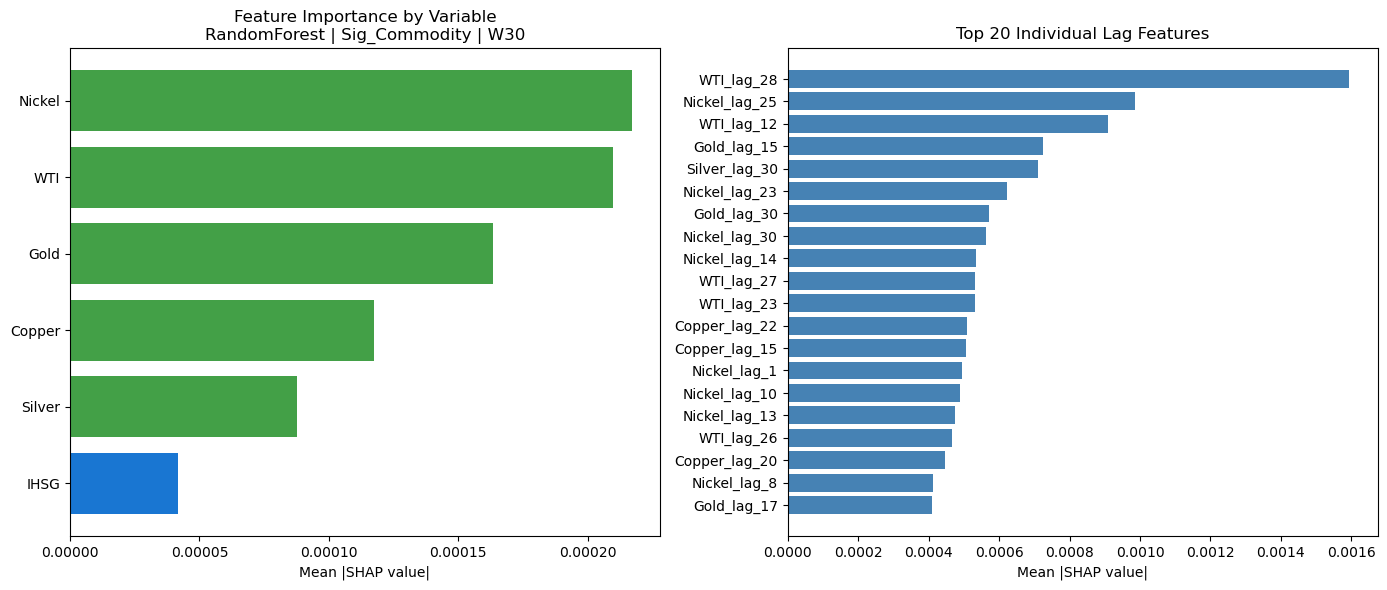

Saved plot.


In [6]:

# Plot: bar chart of variable importance
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: variable-level importance
colors = ['#1976D2' if v == 'IHSG' else '#43A047' if v in LEVEL_VARS else '#E53935' for v in shap_df['Variable']]
axes[0].barh(shap_df['Variable'][::-1], shap_df['Mean_Abs_SHAP'][::-1], color=colors[::-1])
axes[0].set_xlabel("Mean |SHAP value|")
axes[0].set_title(f"Feature Importance by Variable\n{MODEL_NAME} | {COV_NAME} | W{WINDOW}")

# Right: top 20 individual lags
lag_shap = pd.DataFrame({'feature': feat_names, 'mean_abs_shap': np.mean(np.abs(shap_values), axis=0)})
lag_shap = lag_shap.sort_values('mean_abs_shap', ascending=False).head(20)
axes[1].barh(lag_shap['feature'][::-1], lag_shap['mean_abs_shap'][::-1], color='steelblue')
axes[1].set_xlabel("Mean |SHAP value|")
axes[1].set_title("Top 20 Individual Lag Features")

plt.tight_layout()
plt.savefig(f"plot_shap_importance_{MODEL_NAME}_{WINDOW}.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved plot.")


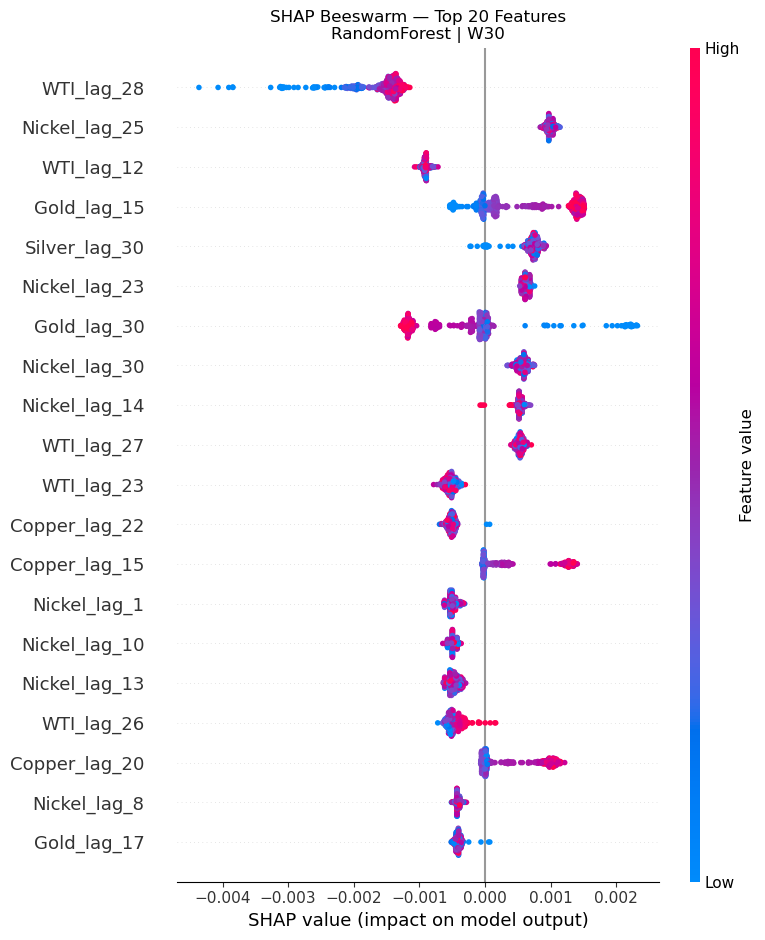

In [7]:

# SHAP summary plot (beeswarm) for top 20 features
top20_idx = lag_shap.index.tolist()[::-1]  # ascending order for shap plot
feat_names_top20 = [feat_names[i] for i in top20_idx]
X_top20 = X_sample[:, top20_idx]

fig, ax = plt.subplots(figsize=(8, 8))
shap.summary_plot(
    shap_values[:, top20_idx], X_top20,
    feature_names=feat_names_top20,
    show=False, max_display=20, plot_type="dot",
)
plt.title(f"SHAP Beeswarm — Top 20 Features\n{MODEL_NAME} | W{WINDOW}")
plt.tight_layout()
plt.savefig(f"plot_shap_beeswarm_{MODEL_NAME}_{WINDOW}.png", dpi=150, bbox_inches='tight')
plt.show()
